In [1]:
%cd /mnt/sda/xxy/Project/ClustView

/mnt/sda/xxy/Project/ClustView


In [4]:

import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"] = '0'  #代表只使用第 个gpu

import torch
import numpy as np

from omegaconf import OmegaConf
from torch.utils.data import DataLoader

from data.data_util import ModelNet40
from output.ModelNet40.ClustView.Baseline_PE_BSP.ClustView import ClustView_cls as ClustView_A
from output.ModelNet40.ClustView.Baseline_RP_BHC.ClustView import ClustView_cls as ClustView_B
from output.ModelNet40.ClustView.Baseline_RP_BHC_PE_BSP.ClustView import ClustView_cls as ClustView_F

baselineA_data = OmegaConf.load('./output/ModelNet40/ClustView/Baseline_PE_BSP/modelnet40.yaml')
baselineA_train = OmegaConf.load('./output/ModelNet40/ClustView/Baseline_PE_BSP/train_cls.yaml')

baselineB_data = OmegaConf.load('./output/ModelNet40/ClustView/Baseline_RP_BHC/modelnet40.yaml')
baselineB_train = OmegaConf.load('./output/ModelNet40/ClustView/Baseline_RP_BHC/train_cls.yaml')

baselineF_data = OmegaConf.load('./output/ModelNet40/ClustView/Baseline_RP_BHC_PE_BSP/modelnet40.yaml')
baselineF_train = OmegaConf.load('./output/ModelNet40/ClustView/Baseline_RP_BHC_PE_BSP/train_cls.yaml')

args_baselineA = OmegaConf.merge(baselineA_data, baselineA_train)
args_baselineB = OmegaConf.merge(baselineB_data, baselineB_train)
args_baselineF = OmegaConf.merge(baselineF_data, baselineF_train)

print('Done!')

Done!


In [5]:
device = torch.device("cuda")

pretrained_A_path = './output/ModelNet40/ClustView/Baseline_PE_BSP/model.pth'
pretrained_A_model = torch.load(pretrained_A_path)

pretrained_B_path = './output/ModelNet40/ClustView/Baseline_RP_BHC/model.pth'
pretrained_B_model = torch.load(pretrained_B_path)

pretrained_F_path = './output/ModelNet40/ClustView/Baseline_RP_BHC_PE_BSP/model.pth'
pretrained_F_model = torch.load(pretrained_F_path)

model_A = ClustView_A(args_baselineA).to(device)
model_A.load_state_dict(pretrained_A_model['model_state_dict'])

model_B = ClustView_B(args_baselineB).to(device)
model_B.load_state_dict(pretrained_B_model['model_state_dict'])

model_F = ClustView_F(args_baselineF).to(device)
model_F.load_state_dict(pretrained_F_model['model_state_dict'])

print('Done!')

Done!


# ModelNet40

In [6]:
data_path = '/mnt/sda/xxy/Dataset/'

test_loader_1 = DataLoader(ModelNet40(data_dir=data_path, num_points=args_baselineA.num_points, partition='test'),
                           batch_size=128, shuffle=True)

print('Done !!')

ValueError: need at least one array to concatenate

# ScanObjectNN

In [4]:
feats_test_A = []
labels_test_A = []

feats_test_B = []
labels_test_B = []

feats_test_F = []
labels_test_F = []

model_A = model_A.eval()
model_B = model_B.eval()
model_F = model_F.eval()

dataset = "ModelNet40" # Choose Dataset ["ModelNet40, ScanObjectNN"]
for i, (data, label) in enumerate(test_loader_1):

    labels = list(map(lambda x: x[0], label.numpy().tolist()))

    data = data.to(device)
    with torch.no_grad():
        featsA = model_A(data)
        featsB = model_B(data)
        featsF = model_F(data)

    featsA = featsA.detach().cpu().numpy()
    featsB = featsB.detach().cpu().numpy()
    featsF = featsF.detach().cpu().numpy()

    for feat in featsA:
        feats_test_A.append(feat)

    for feat in featsB:
        feats_test_B.append(feat)

    for feat in featsF:
        feats_test_F.append(feat)

    labels_test_A += labels
    labels_test_B += labels
    labels_test_F += labels

feats_test_A = np.array(feats_test_A)
labels_test_A = np.array(labels_test_A)

feats_test_B = np.array(feats_test_B)
labels_test_B = np.array(labels_test_B)

feats_test_F = np.array(feats_test_F)
labels_test_F = np.array(labels_test_F)

print(feats_test_A.shape)
print('Done !!')

(2468, 40)
Done !!


### t-SNE visualization

In [5]:
import pandas as pd

from sklearn.manifold import TSNE

feats_test_A_embedded = TSNE(n_components=2, learning_rate='auto', init='random').fit_transform(feats_test_A)
feats_test_B_embedded = TSNE(n_components=2, learning_rate='auto', init='random').fit_transform(feats_test_B)
feats_test_F_embedded = TSNE(n_components=2, learning_rate='auto', init='random').fit_transform(feats_test_F)

print('Done !!')

Done !!


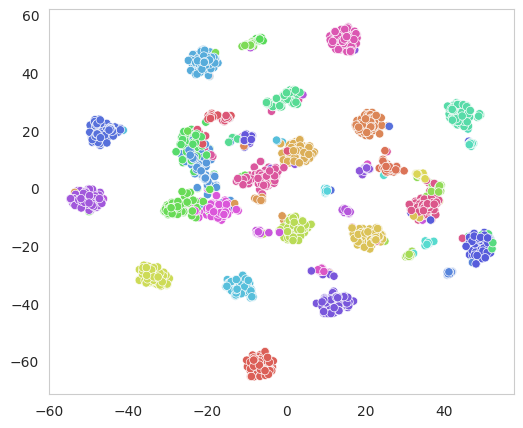

Done !!


In [6]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_style('whitegrid')

df_A = pd.DataFrame()
# "y" represents the number of samples
df_A['label'] = labels_test_A
df_A['axis-0'] = feats_test_A_embedded[:, 0]
df_A['axis-1'] = feats_test_A_embedded[:, 1]

figsize = (6, 5)
fig, ax = plt.subplots(figsize=figsize)
mn_ax = sns.scatterplot(ax=ax, x="axis-0", y="axis-1", hue=df_A.label.tolist(),
                        # palette=sns.color_palette(palette='Set2', n_colors=40),
                        # s=50,
                        palette=sns.color_palette("hls", 40),
                        data=df_A, legend=False)#.set(title="CrossFormer Pretrained Features on ScanObjectNN")
mn_ax.set(xlabel=None)
mn_ax.set(ylabel=None)

plt.grid(False)
plt.show()

res_fig = mn_ax.get_figure()
res_fig.savefig('./vis_util/visualization/tsne/baseline_a.png', dpi=1000.0)

print('Done !!')

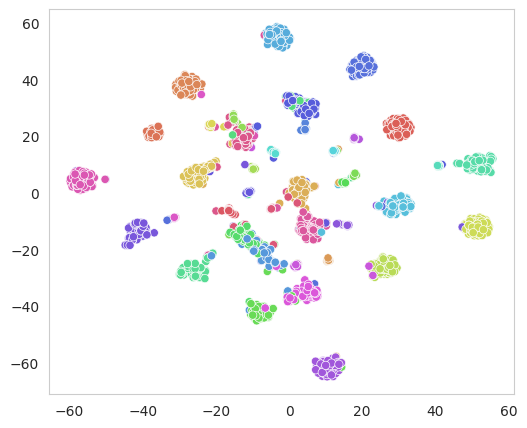

Done !!


In [7]:
df_B = pd.DataFrame()
# "y" represents the number of samples
df_B['label'] = labels_test_B
df_B['axis-0'] = feats_test_B_embedded[:, 0]
df_B['axis-1'] = feats_test_B_embedded[:, 1]

figsize = (6, 5)
fig, ax = plt.subplots(figsize=figsize)
mn_ax = sns.scatterplot(ax=ax, x="axis-0", y="axis-1", hue=df_B.label.tolist(),
                        # palette=sns.color_palette(palette='Set2', n_colors=40),
                        # s=50,
                        palette=sns.color_palette("hls", 40),
                        data=df_B, legend=False)#.set(title="CrossFormer Pretrained Features on ScanObjectNN")
mn_ax.set(xlabel=None)
mn_ax.set(ylabel=None)

plt.grid(False)
plt.show()

res_fig = mn_ax.get_figure()
res_fig.savefig('./vis_util/visualization/tsne/baseline_b.png', dpi=1000.0)

print('Done !!')

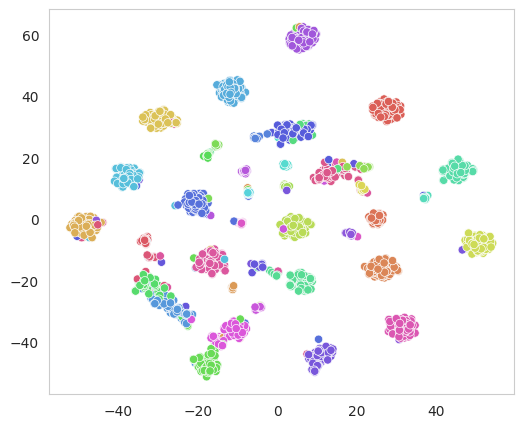

Done !!


In [8]:
df_F = pd.DataFrame()
# "y" represents the number of samples
df_F['label'] = labels_test_F
df_F['axis-0'] = feats_test_F_embedded[:, 0]
df_F['axis-1'] = feats_test_F_embedded[:, 1]

figsize = (6, 5)
fig, ax = plt.subplots(figsize=figsize)
mn_ax = sns.scatterplot(ax=ax, x="axis-0", y="axis-1", hue=df_F.label.tolist(),
                        # palette=sns.color_palette(palette='Set2', n_colors=40),
                        # s=50,
                        palette=sns.color_palette("hls", 40),
                        data=df_F, legend=False)#.set(title="CrossFormer Pretrained Features on ScanObjectNN")
mn_ax.set(xlabel=None)
mn_ax.set(ylabel=None)

plt.grid(False)
plt.show()

res_fig = mn_ax.get_figure()
res_fig.savefig('./vis_util/visualization/tsne/baseline_f.png', dpi=1000.0)

print('Done !!')